In [1]:
#pip install herbie-data

In [35]:
pip install "herbie-data[extras]"

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/8.9 MB 12.6 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/8.9 MB 13.6 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 13.8 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 13.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contextily 1.6.0 requires xyzservices, which is not installed.


In [36]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Point, Polygon
from tqdm import tqdm, trange
import h5py
import logging

from herbie import Herbie
#from toolbox import EasyMap, pc
#from paint.standard2 import cm_dpt, cm_pcp, cm_rh, cm_tmp, cm_wind

In [6]:
days_months = {1:31, 2:28, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}
np.cumsum([0,0]+list(days_months.values()))

array([  0,   0,  31,  59,  90, 120, 151, 181, 212, 243, 273, 304, 334,
       365])

In [7]:
now = pd.Timestamp.utcnow().floor("1h").tz_localize(None)
dates = pd.date_range(now, periods=6, freq="-1H")
dates

C:\Users\m10921371\AppData\Local\Temp\ipykernel_5128\1831983551.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(now, periods=6, freq="-1H")


DatetimeIndex(['2025-07-27 19:00:00', '2025-07-27 18:00:00',
               '2025-07-27 17:00:00', '2025-07-27 16:00:00',
               '2025-07-27 15:00:00', '2025-07-27 14:00:00'],
              dtype='datetime64[ns]', freq='-1h')

In [8]:
# Find first existing Herbie object
for latest in dates:
    H = Herbie(latest, model="hrrr")
    if H.grib:
        break

💔 Did not find ┊ model=hrrr ┊ product=sfc ┊ 2025-Jul-27 19:00 UTC F00
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2025-Jul-27 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


In [9]:
time = latest 

In [10]:
forecast = 1
if forecast:
    postfix = f'{forecast} hour fcst'
else:
    postfix = 'anl'

In [11]:
H = Herbie(
    time,
    model="hrrr",
    product="sfc", # 'sfc', 'prs', 'nat', 'subh'
    fxx=forecast,
)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2025-Jul-27 18:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ aws


In [12]:
H.inventory()

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,190216.0,0-190216,2025-07-27 18:00:00,2025-07-27 19:00:00,REFC,entire atmosphere,1 hour fcst,:REFC:entire atmosphere:1 hour fcst
1,2,190217,274829.0,190217-274829,2025-07-27 18:00:00,2025-07-27 19:00:00,RETOP,cloud top,1 hour fcst,:RETOP:cloud top:1 hour fcst
2,3,274830,465207.0,274830-465207,2025-07-27 18:00:00,2025-07-27 19:00:00,var discipline=0 center=7 local_table=1 parmca...,entire atmosphere,1 hour fcst,:var discipline=0 center=7 local_table=1 parmc...
3,4,465208,565304.0,465208-565304,2025-07-27 18:00:00,2025-07-27 19:00:00,VIL,entire atmosphere,1 hour fcst,:VIL:entire atmosphere:1 hour fcst
4,5,565305,1904466.0,565305-1904466,2025-07-27 18:00:00,2025-07-27 19:00:00,VIS,surface,1 hour fcst,:VIS:surface:1 hour fcst
...,...,...,...,...,...,...,...,...,...,...
165,166,146254574,146254806.0,146254574-146254806,2025-07-27 18:00:00,2025-07-27 19:00:00,ICEC,surface,1 hour fcst,:ICEC:surface:1 hour fcst
166,167,146254807,147693330.0,146254807-147693330,2025-07-27 18:00:00,2025-07-27 19:00:00,SBT123,top of atmosphere,1 hour fcst,:SBT123:top of atmosphere:1 hour fcst
167,168,147693331,149338081.0,147693331-149338081,2025-07-27 18:00:00,2025-07-27 19:00:00,SBT124,top of atmosphere,1 hour fcst,:SBT124:top of atmosphere:1 hour fcst
168,169,149338082,150684184.0,149338082-150684184,2025-07-27 18:00:00,2025-07-27 19:00:00,SBT113,top of atmosphere,1 hour fcst,:SBT113:top of atmosphere:1 hour fcst


In [15]:
data = {
    "air temperature [K]": {},
    "soil temperature [K]": {},
    "incoming shortwave radiation [W m^-2]": {},
    "precipitation [m s^-1]": {},
    "precipitation rain [m s^-1]": {},
    "precipitation snow [m SWE s^-1]": {},
    "vapor pressure air [Pa]": {},
    "leaf area index [-]": {},
    "volumetric soil moisture content [-]": {},
    "time [s]": np.empty(0),
    "x [m]": np.empty(0),
    "y [m]": np.empty(0),
}

In [16]:
keys = data.keys()
for key in keys:
    print(key, type(data[key]))
    if isinstance(data[key], dict):
        _keys = data[key].keys()
        for _key in _keys:
            if int(_key) > 1:
                break
            print('\t', _key, ': type is', type(data[key][_key]))

air temperature [K] <class 'dict'>
soil temperature [K] <class 'dict'>
incoming shortwave radiation [W m^-2] <class 'dict'>
precipitation [m s^-1] <class 'dict'>
precipitation rain [m s^-1] <class 'dict'>
precipitation snow [m SWE s^-1] <class 'dict'>
vapor pressure air [Pa] <class 'dict'>
leaf area index [-] <class 'dict'>
volumetric soil moisture content [-] <class 'dict'>
time [s] <class 'numpy.ndarray'>
x [m] <class 'numpy.ndarray'>
y [m] <class 'numpy.ndarray'>


In [46]:
year = 2024
month = 1
day = 1
number_of_days = 365

In [47]:
times = pd.date_range(f'{year}-{month}-{day} 06:00:00', periods=int(24*number_of_days), freq="1h")
times

DatetimeIndex(['2024-01-01 06:00:00', '2024-01-01 07:00:00',
               '2024-01-01 08:00:00', '2024-01-01 09:00:00',
               '2024-01-01 10:00:00', '2024-01-01 11:00:00',
               '2024-01-01 12:00:00', '2024-01-01 13:00:00',
               '2024-01-01 14:00:00', '2024-01-01 15:00:00',
               ...
               '2024-12-30 20:00:00', '2024-12-30 21:00:00',
               '2024-12-30 22:00:00', '2024-12-30 23:00:00',
               '2024-12-31 00:00:00', '2024-12-31 01:00:00',
               '2024-12-31 02:00:00', '2024-12-31 03:00:00',
               '2024-12-31 04:00:00', '2024-12-31 05:00:00'],
              dtype='datetime64[ns]', length=8760, freq='h')

In [102]:
forecast = 1
if forecast:
    postfix = f'{forecast} hour fcst'
else:
    postfix = 'anl'

In [49]:
# define your desired geographic point
points = pd.DataFrame({
    "longitude": [-84.264017,-84.378443],
    "latitude": [36.013632,35.959715]
})
urban_site=0
forest_site=1

In [37]:
# load temperature dataset
ds = H.xarray("TMP:2 m above ground:" + postfix, remove_grib=False)

# pick nearest gridpoint
matched = ds.herbie.pick_points(points, method="nearest")

# extract the value
# assuming t2m is variable name
value = matched.t2m.isel(point=0).values

INFO: 🌱 Growing new BallTree...🌳 BallTree grew in 5.3 seconds.
INFO: Saved BallTree to C:\Users\m10921371\data\BallTree\hrrr_1799-1059.pkl


In [50]:
ds.herbie.pick_points(points, method="nearest").t2m.isel(point=urban_site).values

array(273.3866, dtype=float32)

In [51]:
for i in trange(len(times)):
    H = Herbie(times[i], model="hrrr", product="prs", fxx=forecast, verbose=False)
    
    # Air temperature
    ds = H.xarray(":TMP:2 m above ground:"+postfix, remove_grib=False)
    air_temp=ds.herbie.pick_points(points, method="nearest").t2m.isel(point=urban_site).values
    data["air temperature [K]"][str(i)] = air_temp
    # Precipitation rate
    prate = H.xarray(":PRATE:surface:"+postfix, remove_grib=False)
    prate["prate"] /= 1e3 # kg/m2/s = mm/s to m/s 
    precip=prate.herbie.pick_points(points, method="nearest").prate.isel(point=urban_site).values
    data["precipitation [m s^-1]"][str(i)] = precip
    rain = np.where(air_temp >= 273.15, precip, 0)
    snow = np.where(air_temp < 273.15, precip, 0)
    data["precipitation rain [m s^-1]"][str(i)] = rain
    data["precipitation snow [m SWE s^-1]"][str(i)] = snow
    
    # Relative humidity to vapor pressure
    rh = H.xarray(":RH:2 m above ground:"+postfix, remove_grib=False)
    rel_hum=rh.herbie.pick_points(points, method="nearest").r2.isel(point=urban_site).values
    vp = rel_hum/100*611.2*np.exp(17.67*(air_temp-273.15)/(air_temp-273.15+243.5))
    data["vapor pressure air [Pa]"][str(i)] = vp
    
    # Shortwave radiation
    srad = H.xarray(":DSWRF:surface:"+postfix, remove_grib=False)
    shortwave=srad.herbie.pick_points(points, method="nearest").sdswrf.isel(point=urban_site).values
    data["incoming shortwave radiation [W m^-2]"][str(i)] = shortwave
    
    # Soil temperature
    st = H.xarray(":TSOIL:0-0 m below ground:"+postfix, remove_grib=False)
    soil_t=st.herbie.pick_points(points, method="nearest").st.isel(point=urban_site).values
    data["soil temperature [K]"][str(i)] = soil_t

  0%|                                                                                         | 0/8760 [00:00<?, ?it/s]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20240101]


  0%|▏                                                                            | 18/8760 [02:48<23:07:44,  9.52s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20240102]


  0%|▎                                                                            | 42/8760 [06:29<22:20:50,  9.23s/it]

...

100%|██████████████████████████████████████████████████████████████████████████▋| 8730/8760 [25:14:01<04:52,  9.75s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20241230]


100%|██████████████████████████████████████████████████████████████████████████▉| 8754/8760 [25:17:47<00:57,  9.64s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20241231]


100%|███████████████████████████████████████████████████████████████████████████| 8760/8760 [25:18:44<00:00, 10.40s/it]


In [108]:
hf = h5py.File('daymet_data_hourly.h5', 'w')

In [109]:
hf.create_dataset('time [s]', data=np.arange(0,3600*len([arr.item() for key, arr in data["air temperature [K]"].items()]),3600))
hf.create_dataset('air temperature [K]', data=[arr.item() for key, arr in data["air temperature [K]"].items()])
hf.create_dataset('soil temperature [K]', data=[arr.item() for key, arr in data["soil temperature [K]"].items()])
hf.create_dataset('incoming shortwave radiation [W m^-2]', data=[arr.item() for key, arr in data["incoming shortwave radiation [W m^-2]"].items()])
hf.create_dataset('vapor pressure air [Pa]', data=[arr.item() for key, arr in data["vapor pressure air [Pa]"].items()])
hf.create_dataset('precipitation rain [m s^-1]', data=[arr.item() for key, arr in data["precipitation rain [m s^-1]"].items()])
hf.create_dataset('precipitation snow [m SWE s^-1]', data=[arr.item() for key, arr in data["precipitation snow [m SWE s^-1]"].items()])

<HDF5 dataset "precipitation snow [m SWE s^-1]": shape (8760,), type "<f8">

In [114]:
hf.close()

### Compare to daily data from daymet

In [111]:
hf = h5py.File('daymet_data_hourly.h5', 'r')

In [84]:
hd= h5py.File('../data/daymet_data.h5', 'r')

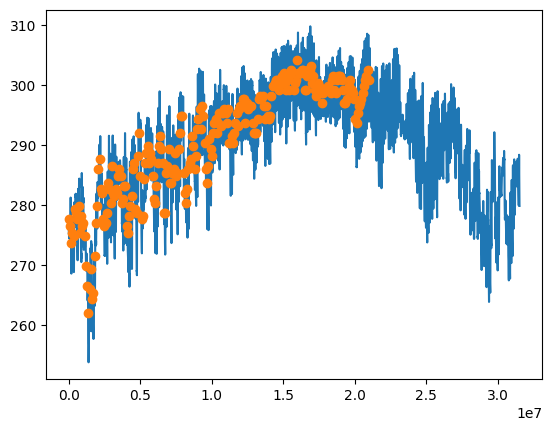

In [88]:
plt.plot(hf['time [s]'][:],hf['air temperature [K]'][:])
plt.plot(hd['time [s]'][2190:]-189216000,hd['air temperature [K]'][2190:],'o')

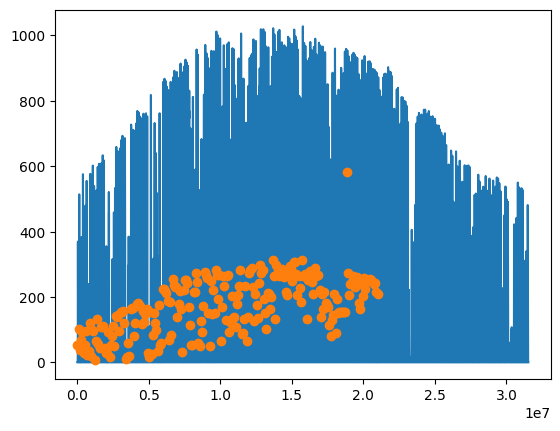

In [90]:
plt.plot(hf['time [s]'][:],hf['incoming shortwave radiation [W m^-2]'][:])
plt.plot(hd['time [s]'][2190:]-189216000,hd['incoming shortwave radiation [W m^-2]'][2190:],'o')

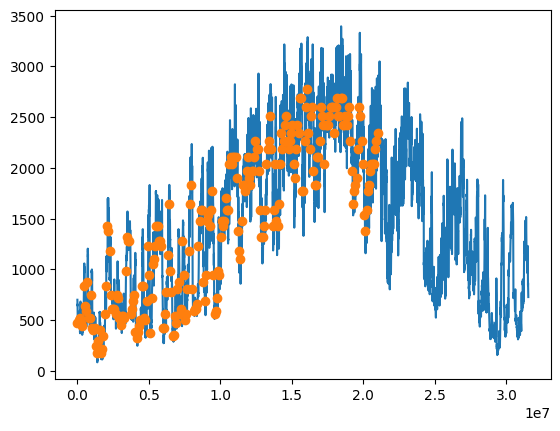

In [97]:
plt.plot(hf['time [s]'][:],hf['vapor pressure air [Pa]'][:])
plt.plot(hd['time [s]'][2190:]-189216000,hd['vapor pressure air [Pa]'][2190:],'o')

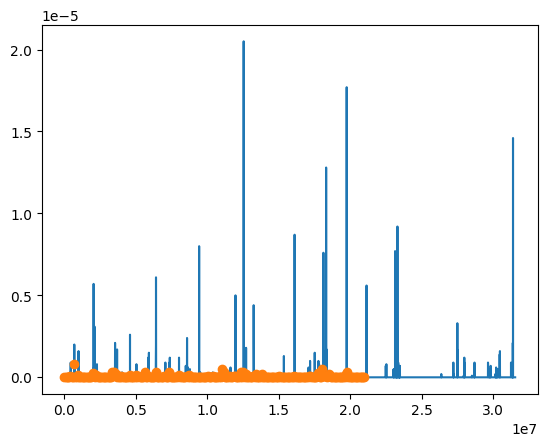

In [112]:
plt.plot(hf['time [s]'][:],hf['precipitation rain [m s^-1]'][:])
plt.plot(hd['time [s]'][2190:]-189216000,hd['precipitation rain [m s^-1]'][2190:],'o')

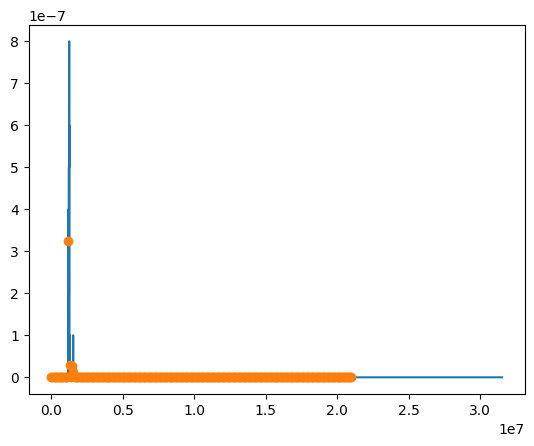

In [113]:
plt.plot(hf['time [s]'][:],hf['precipitation snow [m SWE s^-1]'][:])
plt.plot(hd['time [s]'][2190:]-189216000,hd['precipitation snow [m SWE s^-1]'][2190:],'o')

In [103]:
for i in trange(len(times)):
    H = Herbie(times[i], model="hrrr", product="prs", fxx=forecast, verbose=False)
    H.download(r":PRATE:surface:")
    # Precipitation rate
    prate = H.xarray(":PRATE:surface:"+postfix, remove_grib=False)
    prate["prate"] /= 1e3 # kg/m2/s = mm/s to m/s 
    precip=prate.herbie.pick_points(points, method="nearest").prate.isel(point=urban_site).values
    data["precipitation [m s^-1]"][str(i)] = precip

  0%|▏                                                                             | 18/8760 [00:38<5:17:35,  2.18s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20240102]


  0%|▎                                                                             | 42/8760 [01:32<5:37:41,  2.32s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20240103]


  1%|▌                                                                             | 66/8760 [02:27<5:30:07,  2.28s/it]

...

 47%|██████████████████████████████████▍                                       | 4074/8760 [2:32:24<2:54:02,  2.23s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20240619]


 47%|██████████████████████████████████▌                                       | 4098/8760 [2:33:17<2:49:15,  2.18s/it]

👨🏻‍🏭 Created directory: [C:\Users\m10921371\data\hrrr\20240620]


100%|████████████████████████████████████████████████████████████████████████████| 8760/8760 [5:27:35<00:00,  2.24s/it]


In [105]:
for i in trange(len(times)):
    precip = data["precipitation [m s^-1]"][str(i)] 
    air_temp = data["air temperature [K]"][str(i)]  
    rain = np.where(air_temp >= 273.15, precip, 0)
    snow = np.where(air_temp < 273.15, precip, 0)
    data["precipitation rain [m s^-1]"][str(i)] = rain
    data["precipitation snow [m SWE s^-1]"][str(i)] = snow

100%|███████████████████████████████████████████████████████████████████████████| 8760/8760 [00:00<00:00, 24969.00it/s]
